In [9]:
import numpy as np
import h5py
import math
import seaborn as sns
import tarfile
import pandas as pd
import librosa
from tqdm import tqdm
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model
import tensorflow as tf
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.metrics import det_curve, RocCurveDisplay, DetCurveDisplay, PrecisionRecallDisplay, classification_report

Klasa UBM łączy model NN z modelem LDA, umożliwiając wygodny i zorganizowany sposób tworzenia embeddingów z opcjonalnym postprocessingiem za pomocą LDA.

In [ ]:
class UBM:
    def __init__(self, pretrained_model, lda_model=None):
        #Wczytywanie modelu 
        if isinstance(pretrained_model, str):  #Jeśli podano ścieżkę do pliku
            self.model = load_model(pretrained_model)
        else:
            self.model = pretrained_model
        
        #Wczytywanie modelu LDA
        if lda_model is not None:
            if isinstance(lda_model, str):  #Jeśli podano ścieżkę do pliku
                self.lda = joblib.load(lda_model)
            else:
                self.lda = lda_model
        else:
            self.lda = None

    def extract_embedding(self, X, use_lda=0):
        #Generowanie embeddingów z warstwy bottleneck modelu
        intermediate_layer_model = tf.keras.Model(inputs=self.model.layers[0].input,
                                                  outputs=self.model.layers[-6].output)
        embeddings = intermediate_layer_model.predict(X)
        
        #Przekształcanie embeddingów za pomocą wytrenowanego LDA
        if use_lda and self.lda is not None:
            embeddings = self.lda.transform(embeddings)

        return embeddings



lstm_delta = UBM(pretrained_model = "/kaggle/input/rnn-models-for-ubm/other/default/3/lstm_delta.h5",
                 lda_model = "/kaggle/input/rnn-models-for-ubm/other/default/3/lda.joblib")

SRNN = UBM(pretrained_model = "/kaggle/input/rnn-models-for-ubm/other/default/3/SRNN.h5")

lstm = UBM(pretrained_model = "/kaggle/input/rnn-models-for-ubm/other/default/3/lstm.h5")

gru = UBM(pretrained_model = "/kaggle/input/rnn-models-for-ubm/other/default/3/gru.h5")

Wczytanie danych.

In [11]:
with h5py.File('/kaggle/input/mfcc-data-for-ubm/data.h5', 'r') as f:
    X_emb = f['X_emb'][:]
    X_emb_delta = f['X_emb_delta'][:]
    label = f['labels'][:]
    ID = f['ID'][:]


label_str = label.astype(str) 

Obiekt CNN_UBM posiada metodę extract_embedding, która umożliwia tworzenie embeddingów z opcjonalnym zastosowaniem postprocessingu LDA. Dzięki tej funkcjonalności można uzyskać embeddingi zarówno z redukcją wymiarowości przez LDA, jak i bez niej, co pozwala na porównanie obu podejść. Oraz uśrednianie embeddingów po czasie, wykorzystując kolumnę label.

In [12]:
lstm_delta_lda_odp = lstm_delta.extract_embedding(X_emb_delta, use_lda = 1)
lstm_delta_odp = lstm_delta.extract_embedding(X_emb_delta)
SRNN_odp = SRNN.extract_embedding(X_emb)
lstm_odp = lstm.extract_embedding(X_emb)
gru_odp = gru.extract_embedding(X_emb)


model_df = pd.DataFrame({
    'lstm delta lda': [vec for vec in lstm_delta_lda_odp],
    'lstm delta': [vec for vec in lstm_delta_odp],
    'SRNN': [vec for vec in SRNN_odp],
    'lstm': [vec for vec in lstm_odp],
    'gru': [vec for vec in gru_odp]
})

df_comparison = pd.concat(
    [pd.DataFrame({"ID": ID, "label": label_str}), model_df.reset_index(drop=True)], 
    axis=1
)

#Funkcja do obliczania średnich embeddingów
def compute_average_embedding(group):
    average_embeddings = {col: np.mean(group[col].to_numpy(), axis=0) for col in model_df.columns}
    
    return pd.Series({
        'speaker_ID': group['ID'].iloc[0],
        'File_NAME': group['label'].iloc[0],
        **average_embeddings  #Rozpakowanie średnich embeddingów do wyniku
    })

df_embeddings = (
    df_comparison
    .groupby('label')
    .apply(compute_average_embedding)
    .reset_index(drop=True)
)

df_embeddings.head()

2331/2331 ━━━━━━━━━━━━━━━━━━━━ 57s 24ms/step
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 59s 25ms/step
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step
2331/2331 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step


/tmp/ipykernel_30/1787397282.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_average_embedding)


,speaker_ID,File_NAME,lstm delta lda,lstm delta,SRNN,lstm,gru
0,150,enrollment_150,"[-3.535089428960146, -8.005916514558487, -1.52...","[-0.54111445, -0.56176484, -0.072926834, -0.13...","[-0.39691883, -0.87369907, 0.8325246, 0.642676...","[0.1457046, 0.24451034, 0.7288862, -0.25713295...","[0.9882992, 1.0045516, -1.1148262, 1.2665987e-..."
1,163,enrollment_163,"[12.53113069783425, 2.915108574577954, 3.53876...","[-0.06951367, -0.42151088, 1.3994758, -0.15987...","[1.0763274, 0.28858456, -0.66216576, 0.1372500...","[0.08318762, 0.84878176, -0.36967796, 0.196092...","[0.30570802, -0.4040702, 1.1372408, 1.2665987e..."
2,1723,enrollment_1723,"[8.015662182284716, -3.2733463215365433, -3.02...","[0.49541607, -0.01628605, 0.47265878, 0.553321...","[-0.08075054, -0.63067853, 0.1778755, -0.53193...","[-1.2149497, -0.6131636, 0.6482226, -0.0826964...","[-0.12967242, 0.1722937, -1.4660863, 1.2665987..."
3,1841,enrollment_1841,"[-10.738370525072451, -5.204138753617669, 6.05...","[-1.0014455, -0.48358446, -0.9533472, 0.142491...","[-0.9079301, -0.51585, 0.499808, 0.6468792, 0....","[0.3512939, -0.15632991, 0.07716857, -0.109817...","[-0.1706548, 1.468531, -0.0062540295, 1.266598..."
4,200,enrollment_200,"[-7.809128745017875, 2.536795100151381, 8.4582...","[-0.9998376, -0.7104035, -0.80390376, -0.57570...","[0.31460398, -0.4335719, 0.43571034, -0.208219...","[1.4938037, -0.081898145, 0.0525876, -0.160840...","[-0.12323843, 0.6497837, 0.35407028, 1.2665987..."


Porównanie embeddingów za pomocą podobieństwa cosinusowego dla poszczególnych rodzajów modeli oraz postprocessingu.


In [13]:
def compare_embeddings(embedding1, embedding2):
    return cosine_similarity(embedding1.reshape(1, -1), embedding2.reshape(1, -1))[0][0]

results = []

for speaker_id in tqdm(df_embeddings['speaker_ID'].unique(), desc='Comparison'):
    speaker_df = df_embeddings[df_embeddings['speaker_ID'] == speaker_id]
    
    other_speaker_df = df_embeddings[
        (df_embeddings['speaker_ID'] != speaker_id) &
        (df_embeddings['File_NAME'].str.startswith('test'))
    ]
    
    enrollment_file = speaker_df[speaker_df['File_NAME'] == f'enrollment_{speaker_id}']
    test_files = speaker_df[speaker_df['File_NAME'] != f'enrollment_{speaker_id}']
    
    enrollment_id = enrollment_file['File_NAME'].iloc[0].split('_')[1]
    enrollment_filename = enrollment_file['File_NAME'].iloc[0]

    #Pobieranie embeddingów dla enrollment
    enrollment_embeddings = {
        column: enrollment_file[column].iloc[0]
        for column in ['lstm delta lda', 'SRNN', 'lstm', 'gru', 'lstm delta']
    }
    
    for index, row in test_files.iterrows():
        test_embeddings = {column: row[column] for column in enrollment_embeddings.keys()}
        test_filename = row['File_NAME']
        test_id = test_filename.split('_')[1]

        #Obliczanie wyników dla wszystkich typów embeddingów
        scores = {f'score_{column.replace(" ", "_")}': compare_embeddings(enrollment_embeddings[column], test_embeddings[column]) for column in enrollment_embeddings}
        
        results.append({
            'enrollment_id': enrollment_id,
            'enrollment_filename': enrollment_filename,
            'test_id': test_id,
            'test_filename': test_filename,
            'genuine': 1,
            **scores
        })
        
    for index, row in other_speaker_df.iterrows():
        other_test_embeddings = {column: row[column] for column in enrollment_embeddings.keys()}
        other_test_filename = row['File_NAME']
        other_test_id = other_test_filename.split('_')[1]

        #Obliczanie wyników dla wszystkich typów embeddingów
        scores = {f'score_{column.replace(" ", "_")}': compare_embeddings(enrollment_embeddings[column], other_test_embeddings[column]) for column in enrollment_embeddings}
        
        results.append({
            'enrollment_id': enrollment_id,
            'enrollment_filename': enrollment_filename,
            'test_id': other_test_id,
            'test_filename': other_test_filename,
            'genuine': 0,
            **scores
        })

df_results = pd.DataFrame(results)
# df_results.to_csv('comparison_results.csv', index=False)
df_results.head()

Comparison: 100%|██████████| 50/50 [08:27<00:00, 10.14s/it]


,enrollment_id,enrollment_filename,test_id,test_filename,genuine,score_lstm_delta_lda,score_SRNN,score_lstm,score_gru,score_lstm_delta
0,150,enrollment_150,150,test100_150,1,0.934635,0.560898,0.705471,0.715432,0.731180
1,150,enrollment_150,150,test101_150,1,0.904202,0.475644,0.570037,0.681076,0.528682
2,150,enrollment_150,150,test102_150,1,0.892836,0.476324,0.501670,0.590557,0.465597
3,150,enrollment_150,150,test103_150,1,0.925256,0.524760,0.654132,0.665108,0.671379
4,150,enrollment_150,150,test104_150,1,0.890363,0.411431,0.526450,0.587827,0.437951


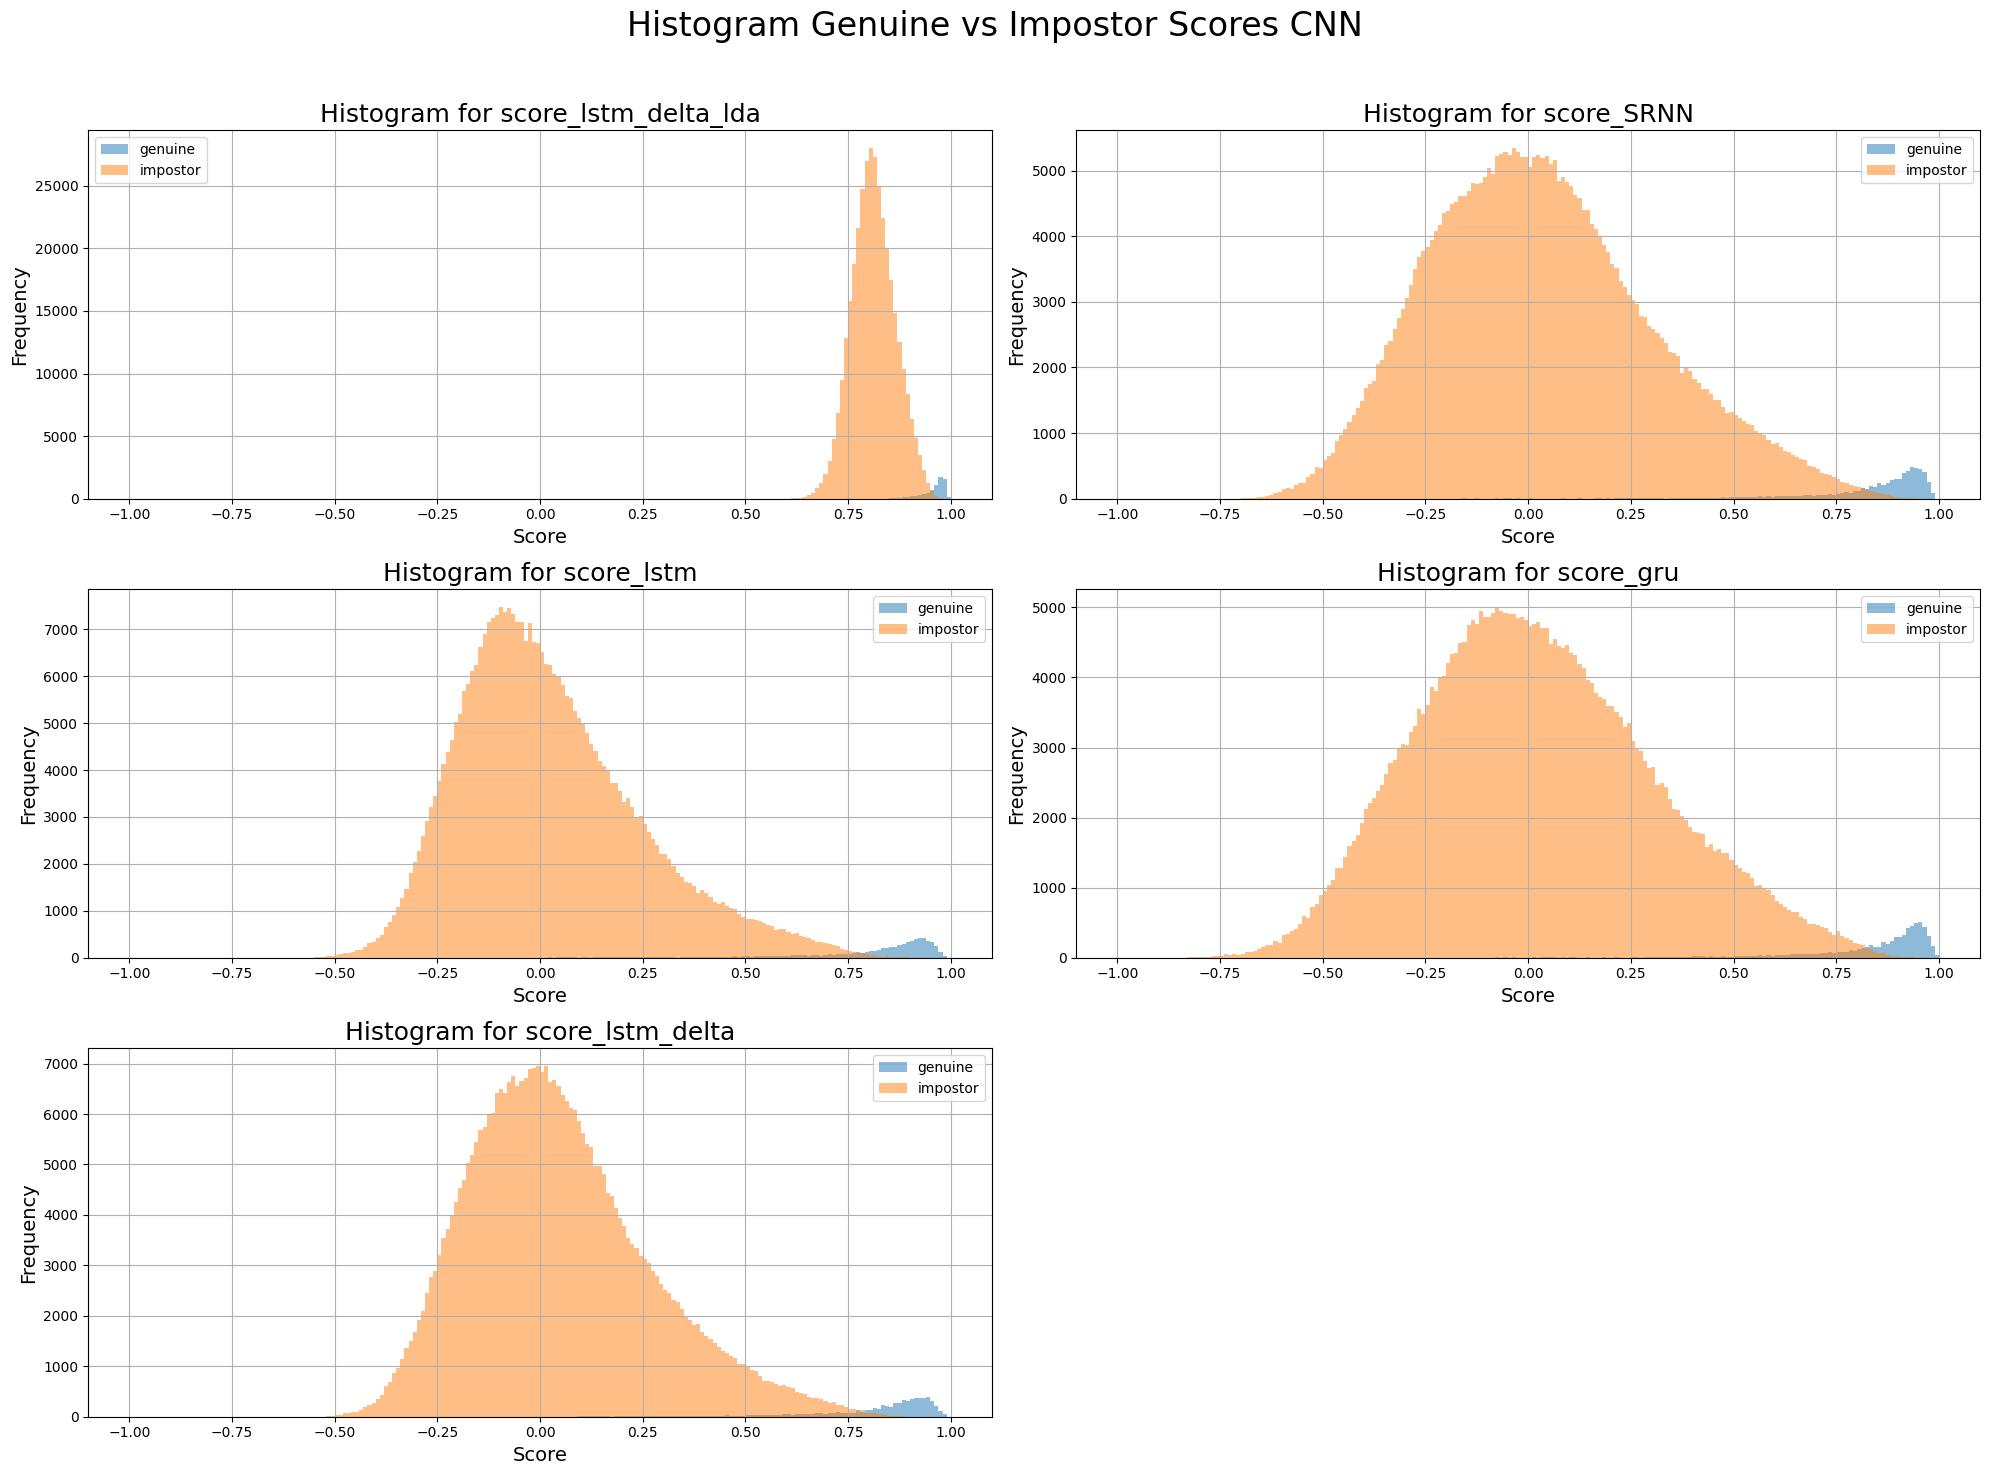

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(20, 15))
fig.suptitle("Histogram Genuine vs Impostor Scores CNN", fontsize=24)

axes = axes.flatten()

score_columns = ['score_lstm_delta_lda', 'score_SRNN', 'score_lstm', 'score_gru', 'score_lstm_delta']
if len(score_columns) > len(axes):
    raise ValueError("Number of score columns exceeds available axes in the figure layout")

params = []

for ax, col in zip(axes, score_columns):
    genuine_scores = df_results[df_results['genuine'] == 1][col]
    impostor_scores = df_results[df_results['genuine'] == 0][col]

    n_TP, bins_TP, _ = ax.hist(genuine_scores, bins=200, range=(-1, 1), alpha=0.5, label="genuine")
    n_TN, bins_TN, _ = ax.hist(impostor_scores, bins=200, range=(-1, 1), alpha=0.5, label="impostor")
    ax.set_title(f"Histogram for {col}", fontsize=18)
    ax.set_xlabel("Score", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.grid()
    ax.legend()
    
    params.append([n_TP, bins_TP, n_TN, bins_TN])

for i in range(len(score_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()

Modele różnią się jakością separacji obu klas. Najlepszą separację wykazuje model score_lstm_delta, gdzie wyniki dla obu grup są najbardziej rozdzielone. W pozostałych modelach, jak score_SRNN czy score_lstm, rozkłady nakładają się, co może utrudniać precyzyjną klasyfikację. Njagorszy wynik jest u score_lstm_delta_lda.

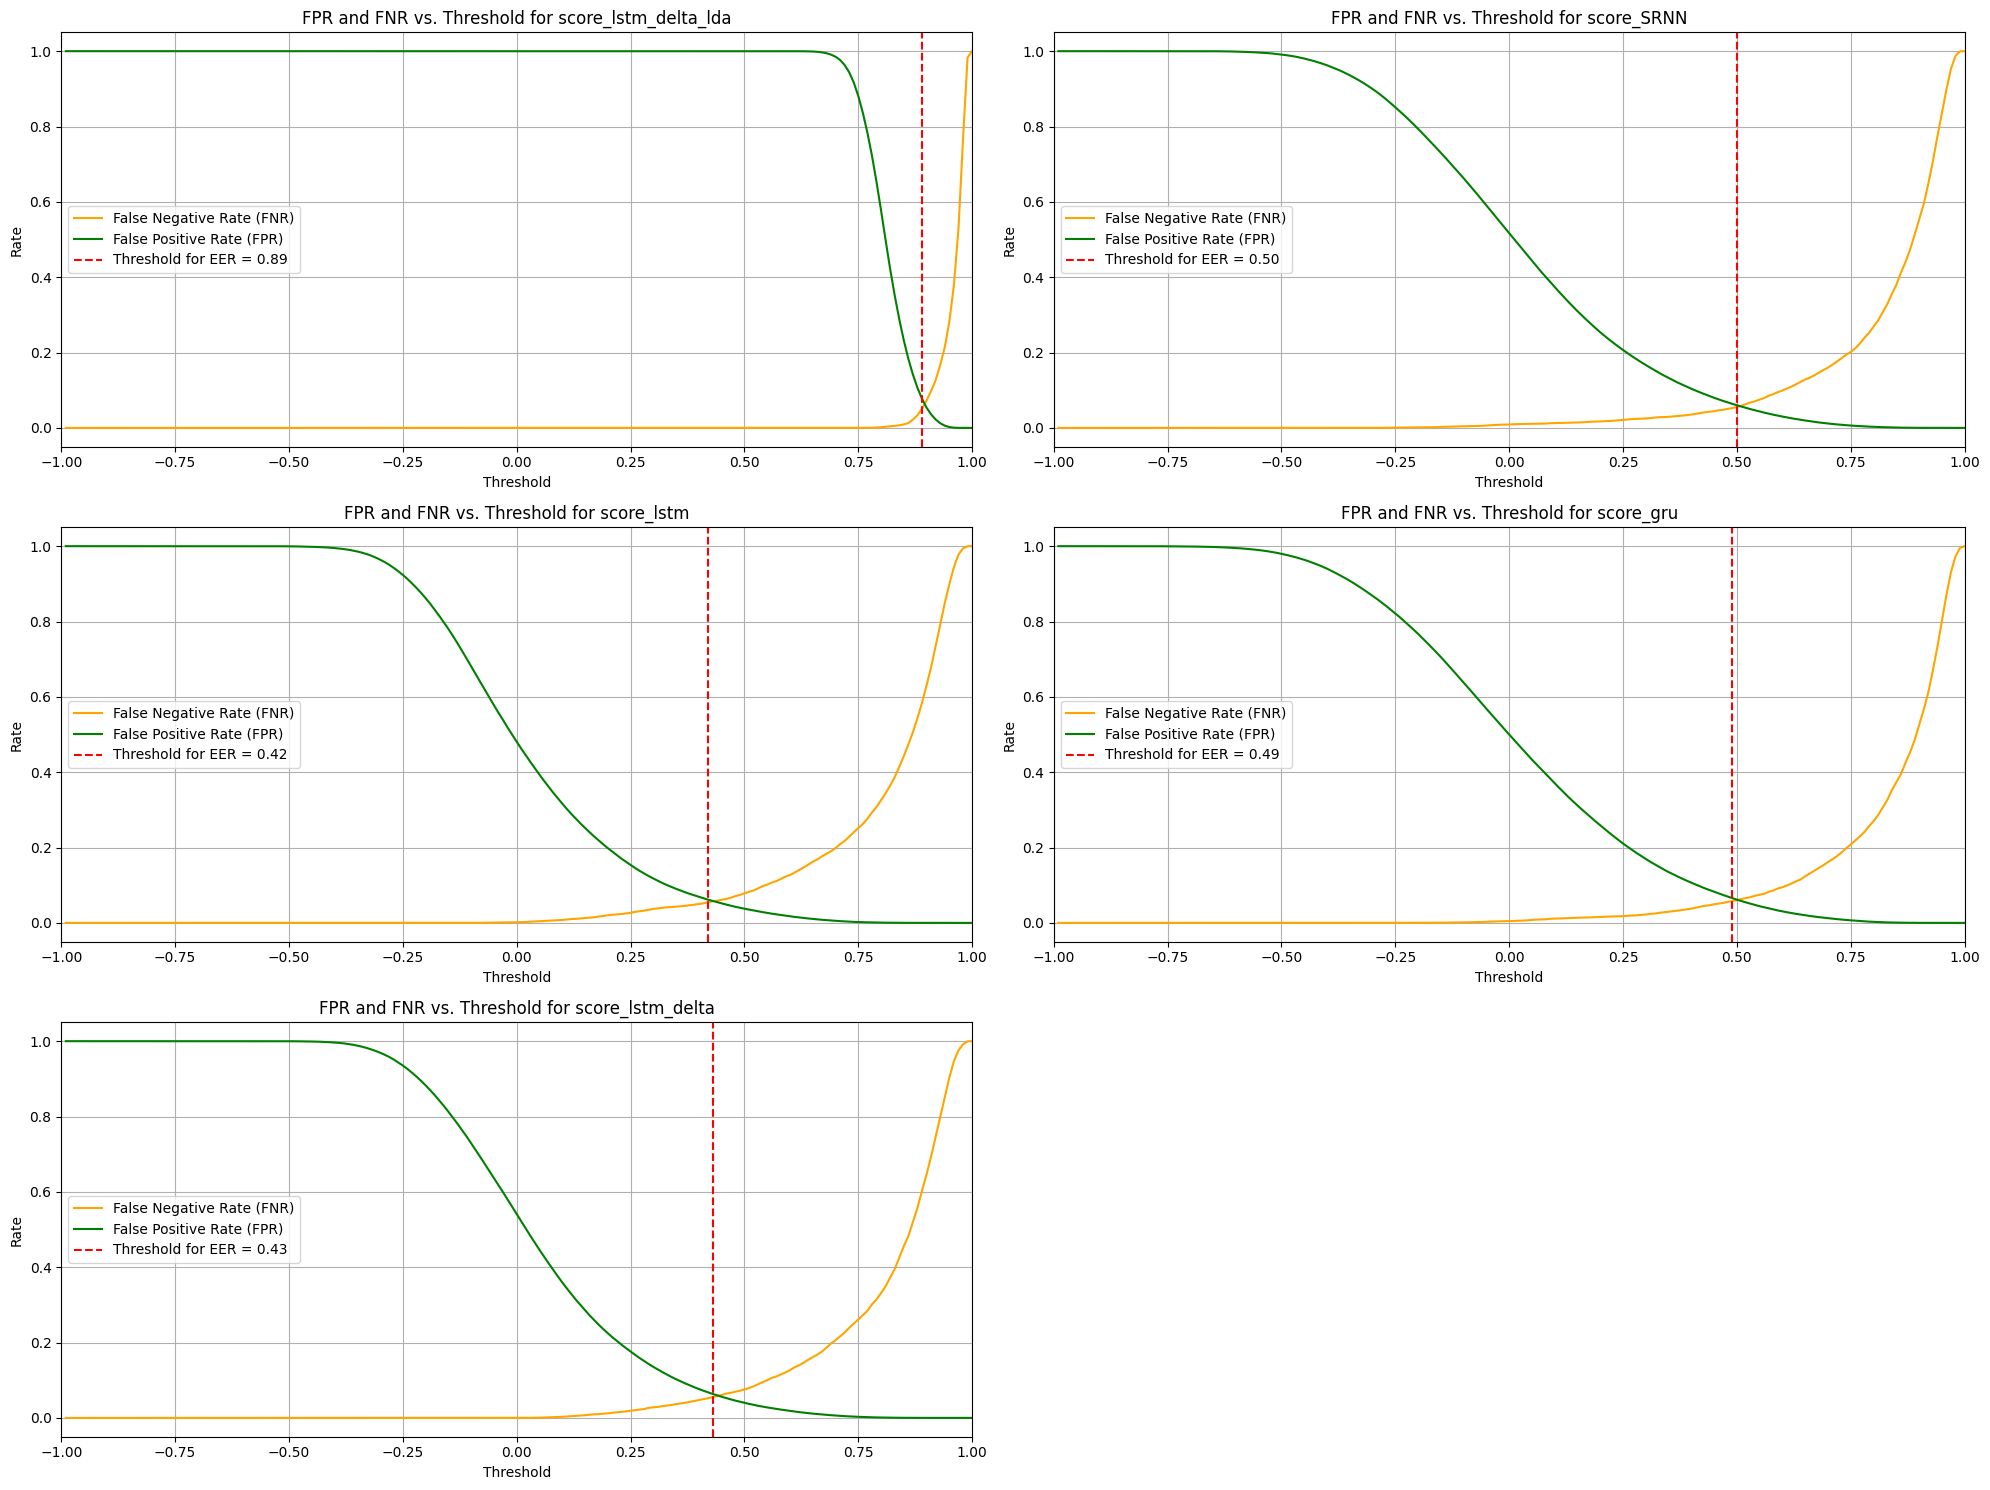

In [15]:
eer_threshold_list = []


num_cols = 2
num_rows = math.ceil(len(score_columns) / num_cols) 

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 15))
axes = axes.flatten()  

for i, col in enumerate(score_columns):
    fnr = np.cumsum(params[i][0]) / np.sum(params[i][0])
    fpr = 1.0 - (np.cumsum(params[i][2]) / np.sum(params[i][2]))
    thresholds = params[i][1]
    
    eer_index = np.argmin(np.abs(fpr - fnr))
    eer_threshold = thresholds[eer_index]
    eer_threshold_list.append(eer_threshold)
    eer_fpr, eer_fnr = fpr[eer_index], fnr[eer_index]
    
    ax = axes[i]
    ax.plot(thresholds[1:], fnr, label="False Negative Rate (FNR)", color='orange')
    ax.plot(thresholds[1:], fpr, label="False Positive Rate (FPR)", color='green')
    ax.axvline(eer_threshold, color='red', linestyle="--", 
               label=f"Threshold for EER = {eer_threshold:.2f}")
    ax.set_xlim(-1, 1)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Rate")
    ax.set_title(f"FPR and FNR vs. Threshold for {col}")
    ax.legend(loc="best")
    ax.grid()

for i in range(len(score_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Na wykresach przedstawiono zależność między wskaźnikami FPR i FNR a progiem decyzyjnym dla różnych typów embeddingów. Czerwona linia na każdym wykresie wskazuje próg, przy którym wartości FPR i FNR są sobie równe, co odpowiada wartości EER.


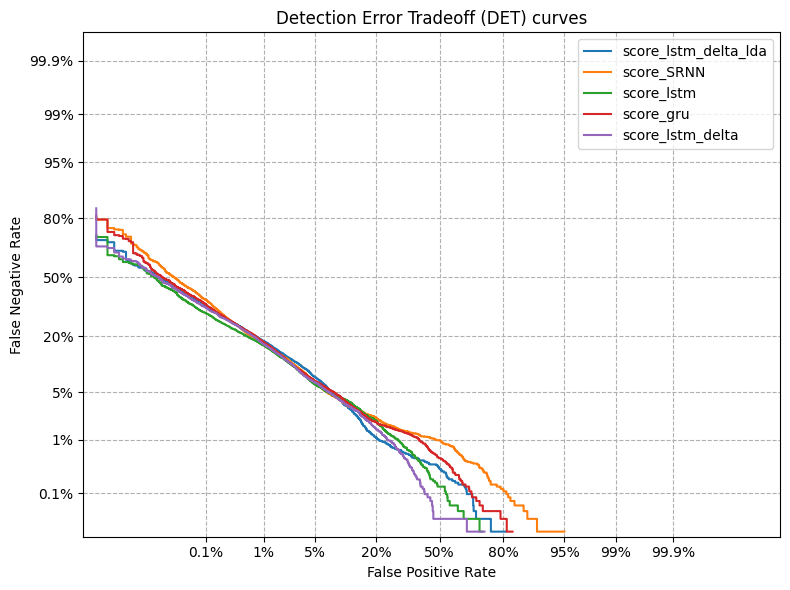

In [16]:
fig, ax_det = plt.subplots(figsize=(8, 6))

for col in score_columns:
    DetCurveDisplay.from_predictions(df_results['genuine'], df_results[col], ax=ax_det, name=col)

ax_det.set_title("Detection Error Tradeoff (DET) curves")
ax_det.set_xlabel("False Positive Rate")
ax_det.set_ylabel("False Negative Rate")
ax_det.grid(linestyle="--")
ax_det.set_xlim(-4.71, 4.5)  
ax_det.set_ylim(-3.71, 3.5)

plt.legend(loc="best")
plt.tight_layout()
plt.show()

Najlepszy model charakteryzuje się krzywą znajdującą się najbliżej dolnego lewego rogu, co oznacza minimalizację obu błędów jednocześnie. Spośród analizowanych modeli, score_lstm_delta wydaje się osiągać najniższe wartości FPR i FNR w kluczowych obszarach, co sugeruje jego przewagę w detekcji. Modele score_lstm_delta i score_lstm również wykazują dobre wyniki, jednak ich krzywe są nieco dalej od optymalnego punktu. Pozostałe modele, takie jak score_gru, prezentują większe wartości błędów, co może świadczyć o niższej skuteczności klasyfikacji.